***ANI Final Project Code - Zachary Asawesna***

Importin Libraries

In [16]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import numpy as np
from sklearn.model_selection import KFold
from tqdm import tqdm
import torchani

import gc
import time
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from torch.utils.data import Dataset, DataLoader

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device) #gpu wouldnt work

cuda


In [3]:
def timeit(f):

    def timed(*args, **kw):

        ts = time.time()
        result = f(*args, **kw)
        te = time.time()

        print(f'func: {f.__name__} took: {te-ts:.4f} sec')
        return result

    return timed

In [4]:
def init_aev_computer():
    Rcr = 5.2
    Rca = 3.5
    EtaR = torch.tensor([16], dtype=torch.float, device=device)
    ShfR = torch.tensor([
        0.900000, 1.168750, 1.437500, 1.706250, 
        1.975000, 2.243750, 2.512500, 2.781250, 
        3.050000, 3.318750, 3.587500, 3.856250, 
        4.125000, 4.393750, 4.662500, 4.931250
    ], dtype=torch.float, device=device)


    EtaA = torch.tensor([8], dtype=torch.float, device=device)
    Zeta = torch.tensor([32], dtype=torch.float, device=device)
    ShfA = torch.tensor([0.90, 1.55, 2.20, 2.85], dtype=torch.float, device=device)
    ShfZ = torch.tensor([
        0.19634954, 0.58904862, 0.9817477, 1.37444680, 
        1.76714590, 2.15984490, 2.5525440, 2.94524300
    ], dtype=torch.float, device=device)

    num_species = 4
    aev_computer = torchani.AEVComputer(
        Rcr, Rca, EtaR, ShfR, EtaA, Zeta, ShfA, ShfZ, num_species
    )
    return aev_computer

aev_computer = init_aev_computer()
aev_dim = aev_computer.aev_length
print(aev_dim)

384


In [5]:
def load_ani_dataset(dspath):
    self_energies = torch.tensor([
        0.500607632585, -37.8302333826,
        -54.5680045287, -75.0362229210
    ], dtype=torch.float, device=device)
    energy_shifter = torchani.utils.EnergyShifter(None)
    species_order = ['H', 'C', 'N', 'O']

    dataset = torchani.data.load(dspath)
    dataset = dataset.subtract_self_energies(energy_shifter, species_order)
    dataset = dataset.species_to_indices(species_order)
    dataset = dataset.shuffle()
    return dataset

dataset = load_ani_dataset("./ani_gdb_s01_to_s04.h5")
# Use dataset.split method to do split
train_data, val_data, test_data = dataset.split(0.8, 0.1, 0.1)

In [6]:
batch_size = 8192 # from 8192
# use dataset.collate(...a).cache() method to do batching
train_data_loader = train_data.collate(batch_size).cache()
val_data_loader = val_data.collate(batch_size).cache()
test_data_loader = test_data.collate(batch_size).cache()

In [8]:
class ANITrainer:
    def __init__(self, model, batch_size, learning_rate, epoch, l2):
        self.model = model
        
        num_params = sum(item.numel() for item in model.parameters())
        print(f"{model.__class__.__name__} - Number of parameters: {num_params}")
        
        self.batch_size = batch_size
        self.optimizer = torch.optim.Adam(model.parameters(), learning_rate, weight_decay=l2)
        self.epoch = epoch
    @timeit
    def train(self, train_data, val_data, early_stop=True, draw_curve=True):
        self.model.train()
        # init data loader
        print("Initialize training data...")
        train_data_loader = train_data.collate(batch_size).cache() # DataLoader(train_data, batch_size=self.batch_size, shuffle=True)
        
        # definition of loss function: MSE is a good choice! 
        loss_func = nn.MSELoss()
        
        # record epoch losses
        train_loss_list = []
        val_loss_list = []
        lowest_val_loss = np.inf
        weights = None
        
        for i in tqdm(range(self.epoch), leave=True):
            train_epoch_loss = 0.0
            for train_data_batch in train_data_loader:
                
                # compute energies
                species = train_data_batch['species'].to(device)
                coords = train_data_batch['coordinates'].to(device)
                true_energies = train_data_batch['energies'].to(device).float()
                _, pred_energies = self.model((species, coords))
                
                # compute loss
                batch_loss = loss_func(pred_energies, true_energies)
                
                # do a step
                self.optimizer.zero_grad()
                batch_loss.backward()
                self.optimizer.step()
                
                batch_importance = true_energies.shape[0] / len(train_data)
                train_epoch_loss += batch_loss.detach().cpu().item() * batch_importance
            
            # use the self.evaluate to get loss on the validation set 
            val_epoch_loss = self.evaluate(val_data, draw_plot = False)
            
            # append the losses
            train_loss_list.append(train_epoch_loss)
            val_loss_list.append(val_epoch_loss)

            
            if early_stop:
                if val_epoch_loss < lowest_val_loss:
                    lowest_val_loss = val_epoch_loss
                    weights = self.model.state_dict()
        
        if draw_curve:
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.set_yscale("log")
            # Plot train loss and validation loss
            ax.plot(np.arange(self.epoch), train_loss_list, label='Train')
            ax.plot(np.arange(self.epoch), val_loss_list, label='Validation')
            ax.legend()
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Loss")
        
        if early_stop:
            self.model.load_state_dict(weights)
        
        return train_loss_list, val_loss_list
    
    
    def evaluate(self, data, draw_plot=False):
        
        # init data loader
        data_loader = data.collate(self.batch_size).cache()
        
        # init loss function
        loss_func = nn.MSELoss()
        total_loss = 0.0
        
        if draw_plot:
            true_energies_all = []
            pred_energies_all = []
            
        with torch.no_grad():
            for batch_data in data_loader:
                
                # compute energies
                species = batch_data['species'].to(device)
                coords = batch_data['coordinates'].to(device)
                true_energies = batch_data['energies'].to(device).float()
                _, pred_energies = self.model((species, coords))
                
                # compute loss
                batch_loss = loss_func(pred_energies, true_energies)

                batch_importance = true_energies.shape[0] / len(data)
                total_loss += batch_loss.detach().cpu().item() * batch_importance
                
                if draw_plot:
                    true_energies_all.append(true_energies.detach().cpu().numpy().flatten())
                    pred_energies_all.append(pred_energies.detach().cpu().numpy().flatten())

        if draw_plot:
            true_energies_all = np.concatenate(true_energies_all)
            pred_energies_all = np.concatenate(pred_energies_all)
            # Report the mean absolute error
            # The unit of energies in the dataset is hartree
            # please convert it to kcal/mol when reporting the mean absolute error
            # 1 hartree = 627.5094738898777 kcal/mol
            # MAE = mean(|true - pred|)
            hartree2kcalmol = 627.5094738898777 
            mae = np.mean(np.abs(hartree2kcalmol * (true_energies_all - pred_energies_all)))
            
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.scatter(true_energies_all, pred_energies_all, label=f"MAE: {mae:.2f} kcal/mol", s=2)
            ax.set_xlabel("Ground Truth")
            ax.set_ylabel("Predicted")
            xmin, xmax = ax.get_xlim()
            ymin, ymax = ax.get_ylim()
            vmin, vmax = min(xmin, ymin), max(xmax, ymax)
            ax.set_xlim(vmin, vmax)
            ax.set_ylim(vmin, vmax)
            ax.plot([vmin, vmax], [vmin, vmax], color='red')
            ax.legend()
            
            
        return total_loss


Chosen Network Architecture

In [9]:
#Network
class AtomicNet(nn.Module):
    def __init__(self): # Literature mentioned 3-4 hidden layers (chose 3 layers)
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 128),
            nn.LayerNorm(128),
            nn.CELU(alpha=0.1), # changed nn.GELU and nn.ReLU to nn.CELU(),
            nn.Linear(128, 128)
        )
        self.layers2 = nn.Sequential(
            nn.Linear(128, 64),
            nn.CELU(alpha=0.1),
            nn.Linear(64, 64)
        )
        self.layers3 = nn.Sequential(
            nn.Linear(64, 32),
            nn.CELU(alpha=0.1),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        x = self.layers(x)
        x = self.layers2(x)
        return self.layers3(x)

**Notes: Changes to Network Architecture, notes, and results**

*2 layers:* \
decrease output nodes of first hidden layer \
50 -> 40 : MAE 6.5 -> 4.45 

40 -> 30 MAE 4.45 -> 11.15

alter inner nodes for 2nd layer: 20 -> 10 -> MAE 3.63 (384:128:30:10:1)

*3 layers:* \
dropout (2nd hidden layer) -> 0.05 -> MAE 24.1

dropout (2nd layer) -> 0.05, 0.15 -> MAE 24.1

learn_rate 1e-3 -> 1e-4 : MAE ->32.3 ; 

learn_rate 1e-3 -> 1e-4 : MAE ->11.1 ; 

l2_penalty 1e-5 -> 1e-4 : MAE -> 9.1; 

reduce batcj size from 8192 to 2048 -> MAE 2.89

CELU all, dropout last HL (p=0.02) -> 384:128:64:32:1 -> MAE 2.11 60 epocs 4096 batch

CELU all, no dropout -> 384:128:64:32:1 60 epocs 4096 batch -> MAE 1.59 

CELU all, no dropout -? 384:128:64:32:16:1 60 epocs 4096 batch -> MAE 3.44

CELU all, no dropout -? 384:128:64:32:16:1 50 epocs 8192 batch -> MAE 1.76

This model works the best because it takes advantage of the energy "spread" across all molecules. THis could be done ussing the nn.CELU, which enables differntiation at negative values, which was proved to be essential to prevent vanishing gradient and removes the possibility of strictly zero values for negative energies. 

The first training loop developed (Does not consider heavy atoms)

In [10]:
# Reinitialize computer/network
net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

In [ ]:
# initial training loop without considering heavy atom count (50 epochs)
learning_rate = 1e-3
epochs = 50 # start with 50
l2_penalty = 1e-5

trainer = ANITrainer(
    model=model, 
    batch_size=batch_size, 
    learning_rate=learning_rate, 
    epoch=epochs, 
    l2=l2_penalty
)
print("Starting training via ANITrainer...")
train_losses, val_losses = trainer.train(
    train_data=train_data, 
    val_data=val_data, 
    early_stop=True, 
    draw_curve=True
)

test_loss = trainer.evaluate(data=test_data, draw_plot=True)

This training is too close to 2, so we will attempt to improve it further

Updated ANITrainer to calculate MAE for train and val as well

In [19]:
class ANITrainer:
    def __init__(self, model, batch_size, learning_rate, epoch, l2):
        self.model = model
        
        num_params = sum(item.numel() for item in model.parameters())
        print(f"{model.__class__.__name__} - Number of parameters: {num_params}")
        
        self.batch_size = batch_size
        self.optimizer = torch.optim.Adam(model.parameters(), learning_rate, weight_decay=l2)
        self.epoch = epoch

    def compute_mae(self, data):
        data_loader = data.collate(self.batch_size).cache()
        hartree2kcalmol = 627.5094738898777
        true_all, pred_all = [], []

        with torch.no_grad():
            for batch_data in data_loader:
                species = batch_data['species'].to(device)
                coords = batch_data['coordinates'].to(device)
                true_energies = batch_data['energies'].to(device).float()
                _, pred_energies = self.model((species, coords))
                true_all.append(true_energies.detach().cpu().numpy().flatten())
                pred_all.append(pred_energies.detach().cpu().numpy().flatten())

        true_all = np.concatenate(true_all)
        pred_all = np.concatenate(pred_all)
        return np.mean(np.abs(hartree2kcalmol * (true_all - pred_all)))

    @timeit
    def train(self, train_data, val_data, early_stop=True, draw_curve=True):
        self.model.train()
        # init data loader
        print("Initialize training data...")
        train_data_loader = train_data.collate(batch_size).cache()
        
        # definition of loss function: MSE is a good choice! 
        loss_func = nn.MSELoss()
        
        # record epoch losses
        train_loss_list = []
        val_loss_list = []
        lowest_val_loss = np.inf
        weights = None
        
        for i in tqdm(range(self.epoch), leave=True):
            train_epoch_loss = 0.0
            for train_data_batch in train_data_loader:
                
                # compute energies
                species = train_data_batch['species'].to(device)
                coords = train_data_batch['coordinates'].to(device)
                true_energies = train_data_batch['energies'].to(device).float()
                _, pred_energies = self.model((species, coords))
                
                # compute loss
                batch_loss = loss_func(pred_energies, true_energies)
                
                # do a step
                self.optimizer.zero_grad()
                batch_loss.backward()
                self.optimizer.step()
                
                batch_importance = true_energies.shape[0] / len(train_data)
                train_epoch_loss += batch_loss.detach().cpu().item() * batch_importance
            
            # use the self.evaluate to get loss on the validation set 
            val_epoch_loss = self.evaluate(val_data, draw_plot=False)
            
            # append the losses
            train_loss_list.append(train_epoch_loss)
            val_loss_list.append(val_epoch_loss)

            if early_stop:
                if val_epoch_loss < lowest_val_loss:
                    lowest_val_loss = val_epoch_loss
                    weights = self.model.state_dict()
        
        if draw_curve:
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.set_yscale("log")
            ax.plot(np.arange(self.epoch), train_loss_list, label='Train')
            ax.plot(np.arange(self.epoch), val_loss_list, label='Validation')
            ax.legend()
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Loss")
        
        if early_stop:
            self.model.load_state_dict(weights)

        # Print final MAE for train and validation sets
        train_mae = self.compute_mae(train_data)
        val_mae = self.compute_mae(val_data)
        print(f"Final Train MAE: {train_mae:.2f} kcal/mol")
        print(f"Final Val   MAE: {val_mae:.2f} kcal/mol")
        
        return train_loss_list, val_loss_list
    
    
    def evaluate(self, data, draw_plot=False):
        
        # init data loader
        data_loader = data.collate(self.batch_size).cache()
        
        # init loss function
        loss_func = nn.MSELoss()
        total_loss = 0.0
        
        if draw_plot:
            true_energies_all = []
            pred_energies_all = []
            
        with torch.no_grad():
            for batch_data in data_loader:
                
                # compute energies
                species = batch_data['species'].to(device)
                coords = batch_data['coordinates'].to(device)
                true_energies = batch_data['energies'].to(device).float()
                _, pred_energies = self.model((species, coords))
                
                # compute loss
                batch_loss = loss_func(pred_energies, true_energies)

                batch_importance = true_energies.shape[0] / len(data)
                total_loss += batch_loss.detach().cpu().item() * batch_importance
                
                if draw_plot:
                    true_energies_all.append(true_energies.detach().cpu().numpy().flatten())
                    pred_energies_all.append(pred_energies.detach().cpu().numpy().flatten())

        if draw_plot:
            true_energies_all = np.concatenate(true_energies_all)
            pred_energies_all = np.concatenate(pred_energies_all)
            hartree2kcalmol = 627.5094738898777 
            mae = np.mean(np.abs(hartree2kcalmol * (true_energies_all - pred_energies_all)))
            
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.scatter(true_energies_all, pred_energies_all, label=f"MAE: {mae:.2f} kcal/mol", s=2)
            ax.set_xlabel("Ground Truth")
            ax.set_ylabel("Predicted")
            xmin, xmax = ax.get_xlim()
            ymin, ymax = ax.get_ylim()
            vmin, vmax = min(xmin, ymin), max(xmax, ymax)
            ax.set_xlim(vmin, vmax)
            ax.set_ylim(vmin, vmax)
            ax.plot([vmin, vmax], [vmin, vmax], color='red')
            ax.legend()
            
        return total_loss

In [13]:
net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

Sequential - Number of parameters: 322308
Starting training via ANITrainer...
Initialize training data...


100%|██████████| 50/50 [04:51<00:00,  5.83s/it]


Final Train MAE: 5.55 kcal/mol
Final Val   MAE: 5.55 kcal/mol
func: train took: 330.5135 sec


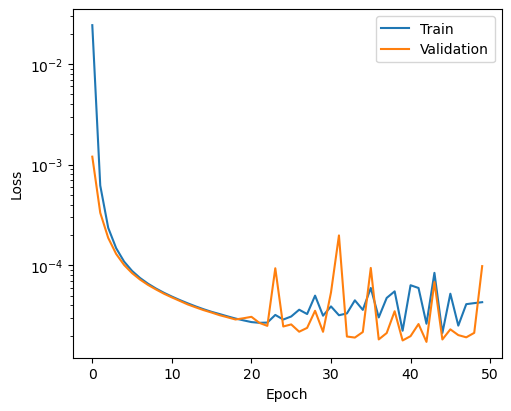

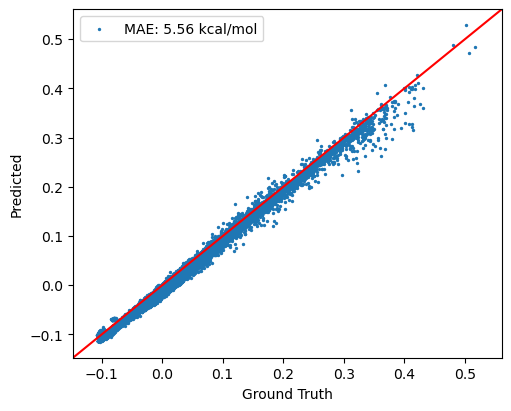

In [14]:
learning_rate = 5e-4 # decrease learning rate
epochs = 50 # start with 50
l2_penalty = 1e-5

trainer = ANITrainer(
    model=model, 
    batch_size=batch_size, 
    learning_rate=learning_rate, 
    epoch=epochs, 
    l2=l2_penalty
)
print("Starting training via ANITrainer...")
train_losses, val_losses = trainer.train(
    train_data=train_data, 
    val_data=val_data, 
    early_stop=True, 
    draw_curve=True
)
test_loss = trainer.evaluate(data=test_data, draw_plot=True)

lr = 5e-4, epochs = 50, l2_pen = 1e-5 -> Train 2.82, Val: 2.82, Test: 2.83

Since test MAE is still greater than 2 kcal/mol, need to continue modifying parameters

Sequential - Number of parameters: 322308
Starting training via ANITrainer...
Initialize training data...


100%|██████████| 60/60 [06:12<00:00,  6.20s/it]


Final Train MAE: 4.22 kcal/mol
Final Val   MAE: 4.21 kcal/mol
func: train took: 416.2920 sec


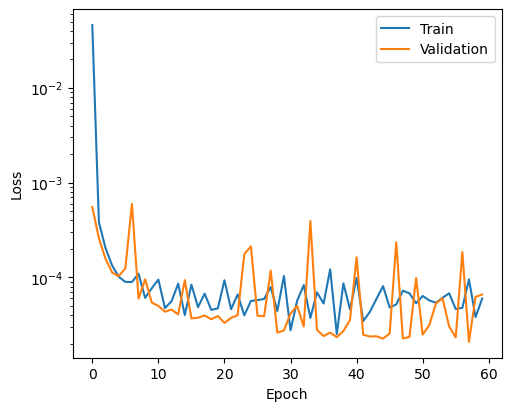

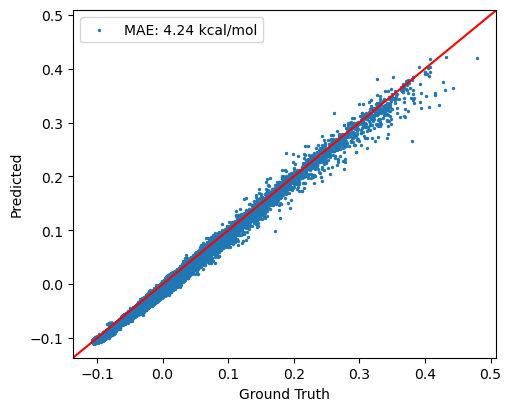

In [10]:
net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

# hyperparameters
learning_rate = 2e-3
epochs = 60 # start with 50
l2_penalty = 1e-5

trainer = ANITrainer(
    model=model, 
    batch_size=batch_size, 
    learning_rate=learning_rate, 
    epoch=epochs, 
    l2=l2_penalty
)
print("Starting training via ANITrainer...")
train_losses, val_losses = trainer.train(
    train_data=train_data, 
    val_data=val_data, 
    early_stop=True, 
    draw_curve=True
)

test_loss = trainer.evaluate(data=test_data, draw_plot=True)

**K-Fold Cross-Validation} (check overfitting)**

Chose 60 epochs to also see if test MAE improves from previous run

In [12]:
def kfold_cross_validation(dataset, n_folds=3, batch_size=1024,
                            learning_rate=1e-3, epochs=60, l2_penalty=1e-5):
    hartree2kcalmol = 627.5094738898777
    fold_size = round(1.0 / n_folds, 6)
    rest_fraction = round(1.0 - fold_size, 6)
    fold_results = []
    data = dataset.shuffle()

    def make_fresh_model():
        return nn.Sequential(
            aev_computer,
            torchani.ANIModel([net_H, net_C, net_N, net_O])
        ).to(device)

    def get_mae(trainer, data_split):
        data_loader = data_split.collate(batch_size).cache()
        true_all, pred_all = [], []
        with torch.no_grad():
            for batch in data_loader:
                species = batch['species'].to(device)
                coords = batch['coordinates'].to(device)
                true_e = batch['energies'].to(device).float()
                _, pred_e = trainer.model((species, coords))
                true_all.append(true_e.cpu().numpy().flatten())
                pred_all.append(pred_e.cpu().numpy().flatten())
        true_all = np.concatenate(true_all)
        pred_all = np.concatenate(pred_all)
        return float(np.mean(np.abs(hartree2kcalmol * (true_all - pred_all))))

    for fold_idx in range(n_folds):
        print(f"FOLD {fold_idx + 1} / {n_folds}")
        test_fold, rest_fold = data.split(fold_size, rest_fraction)
        train_fold, val_fold = rest_fold.split(0.9, 0.1)

        trainer = ANITrainer(
            model=make_fresh_model(),
            batch_size=batch_size,
            learning_rate=learning_rate,
            epoch=epochs,
            l2=l2_penalty
        )
        train_losses, val_losses = trainer.train(
            train_data=train_fold,
            val_data=val_fold,
            early_stop=True,
            draw_curve=False
        )

        train_mae = get_mae(trainer, train_fold)
        test_mae = get_mae(trainer, test_fold)
        print(f"Fold {fold_idx + 1} — Train MAE: {train_mae:.3f} | Test MAE: {test_mae:.3f} kcal/mol")

        fold_results.append({
            'fold': fold_idx + 1,
            'train_mae': train_mae,
            'test_mae': test_mae,
            'train_losses': train_losses,
            'val_losses': val_losses,
        })
        data = data.shuffle().shuffle().shuffle()

    train_maes = np.array([r['train_mae'] for r in fold_results])
    test_maes = np.array([r['test_mae'] for r in fold_results])
    mean_train_mae = train_maes.mean()
    mean_test_mae = test_maes.mean()
    std_test_mae = test_maes.std()

    print(f"\n{'Fold':<6} {'Train MAE':>12} {'Test MAE':>12}")
    
    for r in fold_results:
        print(f"{r['fold']:<6} {r['train_mae']:>11.3f} {r['test_mae']:>11.3f}")

    print(f"{'Mean':<6} {mean_train_mae:>11.3f} {mean_test_mae:>11.3f}")
    print(f"{'Std':<6} {'':>12} {std_test_mae:>11.3f}")
    print(f"\nAvg Train MAE: {mean_train_mae:.3f} kcal/mol")
    print(f"Avg Test MAE: {mean_test_mae:.3f} ± {std_test_mae:.3f} kcal/mol")

    avg_train = np.mean([r['train_losses'] for r in fold_results], axis=0)
    avg_val = np.mean([r['val_losses'] for r in fold_results], axis=0)

    fig, axes = plt.subplots(1, n_folds, figsize=(5 * n_folds, 4), constrained_layout=True)
    axes = [axes] if n_folds == 1 else axes
    for ax, r in zip(axes, fold_results):
        ax.set_yscale("log")
        ax.plot(np.arange(epochs), r['train_losses'], label='Train')
        ax.plot(np.arange(epochs), r['val_losses'], label='Validation')
        ax.set_title(f"Fold {r['fold']} — Test MAE: {r['test_mae']:.2f} kcal/mol")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss (MSE, hartree²)")
        ax.legend()
    plt.suptitle(f"{n_folds}-Fold CV — Mean Test MAE: {mean_test_mae:.3f} ± {std_test_mae:.3f} kcal/mol",
                 fontsize=13, y=1.02)
    plt.show()

    fig, ax = plt.subplots(1, 1, figsize=(6, 4), constrained_layout=True)
    ax.set_yscale("log")
    ax.plot(np.arange(epochs), avg_train, label='Avg Train Loss', linewidth=2)
    ax.plot(np.arange(epochs), avg_val, label='Avg Val Loss', linewidth=2)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Avg Loss (MSE, hartree²)")
    ax.set_title(f"Average Loss Across {n_folds} Folds")
    ax.legend()
    plt.show()

    return fold_results

FOLD 1 / 3
Sequential - Number of parameters: 322308
Initialize training data...


100%|██████████| 50/50 [03:32<00:00,  4.26s/it]


func: train took: 226.5854 sec
Fold 1 — Train MAE: 1.874 | Test MAE: 1.884 kcal/mol
FOLD 2 / 3
Sequential - Number of parameters: 322308
Initialize training data...


100%|██████████| 50/50 [03:32<00:00,  4.24s/it]


func: train took: 225.6898 sec
Fold 2 — Train MAE: 1.809 | Test MAE: 1.816 kcal/mol
FOLD 3 / 3
Sequential - Number of parameters: 322308
Initialize training data...


100%|██████████| 50/50 [03:28<00:00,  4.17s/it]


func: train took: 221.6948 sec
Fold 3 — Train MAE: 2.173 | Test MAE: 2.181 kcal/mol

Fold      Train MAE     Test MAE
1            1.874       1.884
2            1.809       1.816
3            2.173       2.181
Mean         1.952       1.960
Std                       0.158

Avg Train MAE: 1.952 kcal/mol
Avg Test MAE: 1.960 ± 0.158 kcal/mol


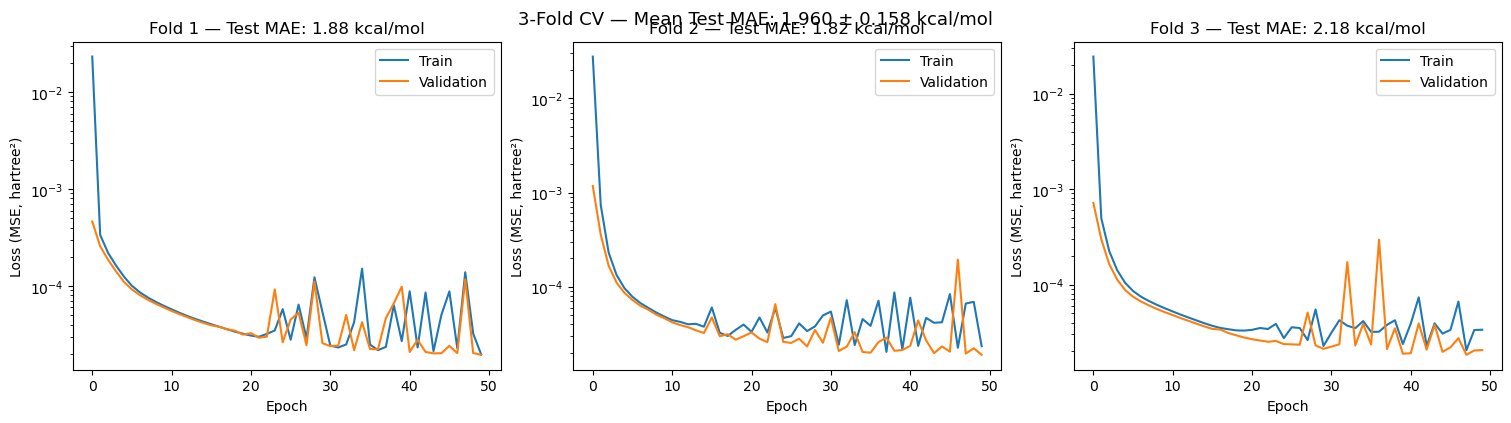

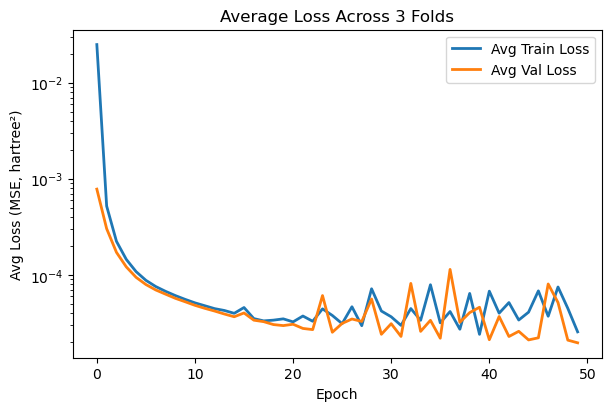

In [13]:
kfold_results = kfold_cross_validation(
    dataset       = dataset,
    n_folds       = 3,
    batch_size    = batch_size,
    learning_rate = 1e-3,
    epochs        = epochs,
    l2_penalty    = 1e-5
)

**K-Fold Results Analysis:**

Does the model architecture perform consistently across the entire dataset? \

-> Yes it does. If we compare the train and test MAE across all folds, we can see that difference between each at every fold is minimal. There is low variance between the folds which means there is low standard deviation. Since the difference between train and test loss is also minimal at each fold, it means the model generalizes well, and we can move on into our analysis




New Training Loop Block w/ modifications to heavy atoms (post-train filtering) and train/validation/test mae calculation

In [33]:
class ANITrainer:
    def __init__(self, model, batch_size, learning_rate, epoch, l2):
        self.model = model
        
        num_params = sum(item.numel() for item in model.parameters())
        print(f"{model.__class__.__name__} - Number of parameters: {num_params}")
        
        self.batch_size = batch_size
        self.optimizer = torch.optim.Adam(model.parameters(), learning_rate, weight_decay=l2)
        self.epoch = epoch
    @timeit
    def train(self, train_data, val_data, early_stop=True, draw_curve=True):
        self.model.train()
        # init data loader
        print("Initialize training data...")
        train_data_loader = train_data.collate(batch_size).cache() # DataLoader(train_data, batch_size=self.batch_size, shuffle=True)
        
        # definition of loss function: MSE is a good choice! 
        loss_func = nn.MSELoss()
        
        # record epoch losses
        train_loss_list = []
        val_loss_list = []
        lowest_val_loss = np.inf
        weights = None
        
        for i in tqdm(range(self.epoch), leave=True):
            train_epoch_loss = 0.0
            for train_data_batch in train_data_loader:
                
                # compute energies
                species = train_data_batch['species'].to(device)
                coords = train_data_batch['coordinates'].to(device)
                true_energies = train_data_batch['energies'].to(device).float()
                _, pred_energies = self.model((species, coords))
                
                # compute loss
                batch_loss = loss_func(pred_energies, true_energies)
                
                # do a step
                self.optimizer.zero_grad()
                batch_loss.backward()
                self.optimizer.step()
                
                batch_importance = true_energies.shape[0] / len(train_data)
                train_epoch_loss += batch_loss.detach().cpu().item() * batch_importance
            
            # use the self.evaluate to get loss on the validation set 
            val_epoch_loss, _ = self.evaluate(val_data, draw_plot = False)
            
            # append the losses
            train_loss_list.append(train_epoch_loss)
            val_loss_list.append(val_epoch_loss)

            
            if early_stop:
                if val_epoch_loss < lowest_val_loss:
                    lowest_val_loss = val_epoch_loss
                    weights = self.model.state_dict()
        
        if draw_curve:
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.set_yscale("log")
            # Plot train loss and validation loss
            ax.plot(np.arange(self.epoch), train_loss_list, label='Train')
            ax.plot(np.arange(self.epoch), val_loss_list, label='Validation')
            ax.legend()
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Loss")
        
        if early_stop:
            self.model.load_state_dict(weights)
        
        return train_loss_list, val_loss_list
    
    
    def evaluate(self, data, draw_plot=False):
        
        # init data loader
        data_loader = data.collate(self.batch_size).cache()
        
        # init loss function
        loss_func = nn.MSELoss()
        total_loss = 0.0
        
        if draw_plot:
            true_energies_all = []
            pred_energies_all = []
            
        with torch.no_grad():
            for batch_data in data_loader:
                
                # compute energies
                species = batch_data['species'].to(device)
                coords = batch_data['coordinates'].to(device)
                true_energies = batch_data['energies'].to(device).float()
                _, pred_energies = self.model((species, coords))
                
                # compute loss
                batch_loss = loss_func(pred_energies, true_energies)

                batch_importance = true_energies.shape[0] / len(data)
                total_loss += batch_loss.detach().cpu().item() * batch_importance
                
                if draw_plot:
                    true_energies_all.append(true_energies.detach().cpu().numpy().flatten())
                    pred_energies_all.append(pred_energies.detach().cpu().numpy().flatten())

        if draw_plot:
            true_energies_all = np.concatenate(true_energies_all)
            pred_energies_all = np.concatenate(pred_energies_all)
            # Report the mean absolute error
            # The unit of energies in the dataset is hartree
            # please convert it to kcal/mol when reporting the mean absolute error
            # 1 hartree = 627.5094738898777 kcal/mol
            # MAE = mean(|true - pred|)
            hartree2kcalmol = 627.5094738898777 
            mae = np.mean(np.abs(hartree2kcalmol * (true_energies_all - pred_energies_all)))
            
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.scatter(true_energies_all, pred_energies_all, label=f"MAE: {mae:.2f} kcal/mol", s=2)
            ax.set_xlabel("Ground Truth")
            ax.set_ylabel("Predicted")
            xmin, xmax = ax.get_xlim()
            ymin, ymax = ax.get_ylim()
            vmin, vmax = min(xmin, ymin), max(xmax, ymax)
            ax.set_xlim(vmin, vmax)
            ax.set_ylim(vmin, vmax)
            ax.plot([vmin, vmax], [vmin, vmax], color='red')
            ax.legend()
            
            return total_loss, mae
            
        return total_loss

    def compute_mae(self, data):
        """Single forward pass returning MAE in kcal/mol."""
        hartree2kcalmol  = 627.5094738898777
        data_loader = data.collate(self.batch_size).cache()
        true_all, pred_all = [], []

        self.model.eval()
        with torch.no_grad():
            for batch in data_loader:
                species = batch['species'].to(device)
                coords = batch['coordinates'].to(device)
                true_e = batch['energies'].to(device).float()
                _, pred_e = self.model((species, coords))
                true_all.append(true_e.cpu().numpy().flatten())
                pred_all.append(pred_e.cpu().numpy().flatten())

        true_all = np.concatenate(true_all)
        pred_all = np.concatenate(pred_all)
        return float(np.mean(np.abs(hartree2kcalmol * (true_all - pred_all))))

    # evaluate_by_heavy_atoms
    def evaluate_by_heavy_atoms(self, data, max_heavy=4): # initial heavy_atom evaluation modification 
        """
        Evaluate MAE grouped by heavy atom count (C, N, O = indices 1, 2, 3).
        Single forward pass — groups filtered in numpy after collection.
        """
        hartree2kcalmol = 627.5094738898777
        data_loader = data.collate(self.batch_size).cache()

        all_true, all_pred, all_heavy_counts = [], [], []

        self.model.eval()
        with torch.no_grad():
            for batch_data in data_loader:
                species = batch_data['species'].to(device)
                coords = batch_data['coordinates'].to(device)
                true_energies = batch_data['energies'].to(device).float()
                _, pred_energies = self.model((species, coords))

                # index > 0 → C, N, O (not H=0, not padding=-1)
                heavy_counts = (species > 0).sum(dim=1)

                all_true.append(true_energies.cpu().numpy().flatten())
                all_pred.append(pred_energies.cpu().numpy().flatten())
                all_heavy_counts.append(heavy_counts.cpu().numpy())

        all_true = np.concatenate(all_true)
        all_pred = np.concatenate(all_pred)
        all_heavy_counts = np.concatenate(all_heavy_counts)

        print("\n── MAE by Heavy Atom Count ──")
        results = {}
        for n in range(1, max_heavy + 1):
            mask = (all_heavy_counts == n)
            if mask.sum() == 0:
                print(f"  {n} heavy atoms: no molecules found")
                continue
            mae = float(np.mean(np.abs(hartree2kcalmol * (all_true[mask] - all_pred[mask]))))
            results[n] = mae
            print(f"  {n} heavy atoms: MAE = {mae:.3f} kcal/mol "
                  f"({mask.sum()} molecules)")

        fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
        ax.plot(list(results.keys()), list(results.values()),
                marker='o', linewidth=2)
        ax.set_xlabel("Number of Heavy Atoms")
        ax.set_ylabel("MAE (kcal/mol)")
        ax.set_title("MAE vs Heavy Atom Count")
        ax.axhline(y=2.0, color='red', linestyle='--', label='2 kcal/mol target')
        ax.legend()
        plt.show()

        return results



In [20]:
#Network (same as before)
class AtomicNet(nn.Module):
    def __init__(self): # Literature mentioned 3-4 hidden layers (chose 3 layers)
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 128),
            nn.LayerNorm(128),
            nn.CELU(alpha=0.1), # nn.CELU(),
            nn.Linear(128, 128)
        )
        self.layers2 = nn.Sequential(
            nn.Linear(128, 64),
            nn.CELU(alpha=0.1),
            nn.Linear(64, 64)
        )
        self.layers3 = nn.Sequential(
            nn.Linear(64, 32),
            nn.CELU(alpha=0.1),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        x = self.layers(x)
        x = self.layers2(x)
        return self.layers3(x)

In [11]:
# Reinitialize computer/network
net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

Sequential - Number of parameters: 322308
Starting training...
Initialize training data...


100%|██████████| 65/65 [06:15<00:00,  5.77s/it]


func: train took: 391.7923 sec


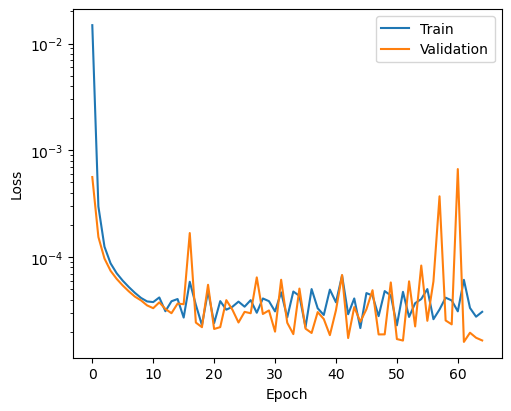

In [18]:
# hyperparameters
learning_rate = 1e-3
epochs = 65 # Changed 50 to 60 epochs
l2_penalty = 1e-5

# trainer initialization
trainer = ANITrainer(
    model=model, 
    batch_size=batch_size, 
    learning_rate=learning_rate, 
    epoch=epochs, 
    l2=l2_penalty
)

# training block 
print("Starting training...")
train_losses, val_losses = trainer.train(
    train_data = train_data,
    val_data   = val_data,
    early_stop = True,
    draw_curve = True            
)

FINAL MODEL:

Using the model architecture above, I was successfully able to output a model with an MAE below 2 kcal/mol without modifying the number of heavy atoms. However, I want to investigate this further with modification of heavy atoms quantity.

Lowest test MAE obtained: 1.70

FINAL METRICS
Split      MAE (kcal/mol)
Train               1.920              N/A
Val                 1.926              N/A
Test                1.923


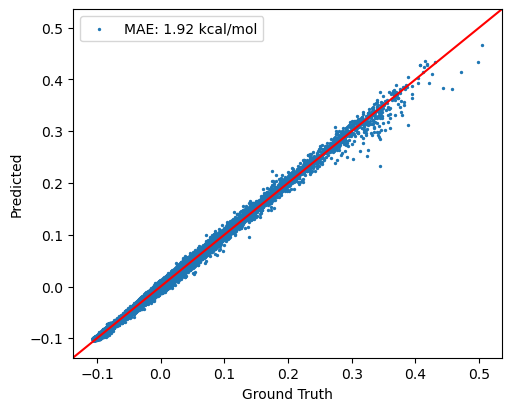

In [19]:
# Evaluate data (all atoms)
test_mse, _ = trainer.evaluate(
    data = test_data,
    draw_plot = True
) # test_mse is the overall loss from MSE loss function

# MAE for all three splits via compute_mae 
train_mae = trainer.compute_mae(train_data)
val_mae = trainer.compute_mae(val_data)
test_mae = trainer.compute_mae(test_data)

print("FINAL METRICS")
print(f"{'Split':<8} {'MAE (kcal/mol)':>16}")
print(f"{'Train':<8} {train_mae:>16.3f} {'N/A':>16}")
print(f"{'Val':<8} {val_mae:>16.3f} {'N/A':>16}")
print(f"{'Test':<8} {test_mae:>16.3f}") 

This was a demonstration of evaluation of molecule energy calculation accuracy given by the max number of heavy atoms. From the output, we can see that the error of the model trained on the entire dataset (including all atoms) is also dependent on the amount of heavy atoms specified during evaluation (1,2,3,4). However, this method filters the heavy atoms after the model has been trainnig, meaning the model has been generalized to minimize the average error across all atoms of different "heaviness". For general prediction, I would use this model and filter during evaluation. 

I could also try filtering to a specified max number of heavy atoms prior to training, which would make the model applicable to the dataset containing those atoms, making the model less generalizable outside of the atom max heaviness range. However, we risk data leakage. I will do this in later code


Evaluating by heavy atom count

── MAE by Heavy Atom Count ──
  1 heavy atoms: MAE = 2.174 kcal/mol (1116 molecules)
  2 heavy atoms: MAE = 2.774 kcal/mol (5116 molecules)
  3 heavy atoms: MAE = 1.870 kcal/mol (15131 molecules)
  4 heavy atoms: MAE = 1.864 kcal/mol (65126 molecules)


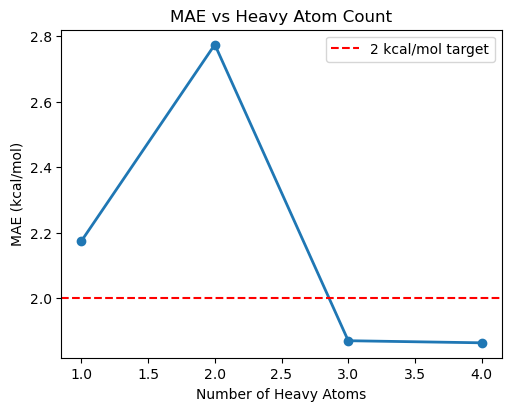

In [20]:
# evaluating impact of number of heavy atoms on test metrics (filtered during evaluation)
print("\nEvaluating by heavy atom count")
heavy_atom_results = trainer.evaluate_by_heavy_atoms(
    data = test_data,
    max_heavy = 4
)
# We see a general decrease in MAE as the max number of heavy atoms increases. 

**Pre-training filtering heavy atoms**

My approach was to use a mask to filter the dataset when ANITrainer is called with an additional input parameter, max_heavy. This filters the species number to be at the specific max_heavy_atom number and below. I also made a new class called ANITrainerHeavy to take advantage of the ANITrainer I made before, while also incorporating my function to filter the ANI dataset to contain only molecules with species that has "heavy" atoms up to the number defined in max_heavy. 



In [24]:
def filter_by_max_heavy_atoms(dataset, max_heavy_atoms, species_order=['H', 'C', 'N', 'O']):
    hydrogen_index = species_order.index('H')
    
    filtered = []
    for batch in dataset:
        species = batch['species']
        heavy_mask = (species != hydrogen_index) & (species != -1)
        if heavy_mask.ndim == 1:
            heavy_count = int(heavy_mask.sum())
        else:
            heavy_count = int(heavy_mask[0].sum())
        if heavy_count <= max_heavy_atoms:
            filtered.append(batch)

    return torchani.data.TransformableIterable(filtered)


def load_ani_dataset2(dspath, max_heavy_atoms=None):
    self_energies = torch.tensor([
        0.500607632585, -37.8302333826,
        -54.5680045287, -75.0362229210
    ], dtype=torch.float, device=device)
    energy_shifter = torchani.utils.EnergyShifter(self_energies)
    species_order = ['H', 'C', 'N', 'O']

    dataset = torchani.data.load(dspath)
    dataset = dataset.subtract_self_energies(energy_shifter, species_order)
    dataset = dataset.species_to_indices(species_order)
    dataset = dataset.shuffle()

    if max_heavy_atoms is not None:
        dataset = filter_by_max_heavy_atoms(dataset, max_heavy_atoms, species_order)

    return dataset

In [33]:
data_heavy = load_ani_dataset2("./ani_gdb_s01_to_s04.h5", max_heavy_atoms=3)

total = len(data_heavy)
n_train = int(total * 0.8)
print(f"Total molecules: {total}")
print(f"Train size: {n_train}")
# Batch size should be a power of 2, no larger than train set
batch_size2 = min(8192, n_train)
# Round down to nearest power of 2 for GPU efficiency
batch_size2 = 2 ** (batch_size2.bit_length() - 1)

print(f"Using batch_size: {batch_size}")
# Pass None for last split so it consumes remainder, avoiding StopIteration from rounding
train_heavy, val_heavy, test_heavy = data_heavy.split(0.8, 0.1, 0.1)

train_data_loader = train_heavy.collate(batch_size2).cache()
val_data_loader = val_heavy.collate(batch_size2).cache()
test_data_loader  = test_heavy.collate(batch_size2).cache()

Total molecules: 212962
Train size: 170369
Using batch_size: 8192


Max heavy atoms of 3

In [34]:
#Network
class AtomicNet(nn.Module):
    def __init__(self): # Literature mentioned 3-4 hidden layers (chose 3 layers)
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 128),
            nn.LayerNorm(128),
            nn.CELU(alpha=0.1), # changed nn.GELU and nn.ReLU to nn.CELU(),
            nn.Linear(128, 128)
        )
        self.layers2 = nn.Sequential(
            nn.Linear(128, 64),
            nn.CELU(alpha=0.1),
            nn.Linear(64, 64)
        )
        self.layers3 = nn.Sequential(
            nn.Linear(64, 32),
            nn.CELU(alpha=0.1),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        x = self.layers(x)
        x = self.layers2(x)
        return self.layers3(x)

Sequential - Number of parameters: 322308
Starting training via ANITrainer...
Initialize training data...


100%|██████████| 65/65 [01:29<00:00,  1.37s/it]


Final Train MAE: 1.70 kcal/mol
Final Val   MAE: 1.72 kcal/mol
func: train took: 100.4814 sec


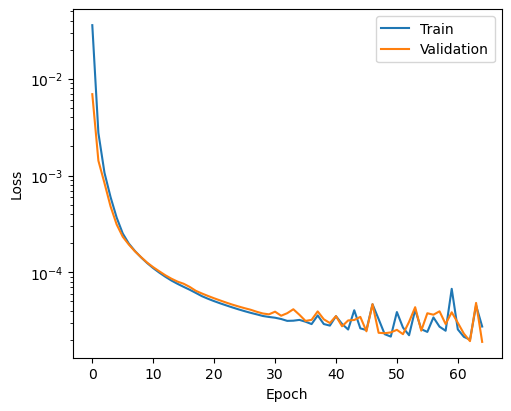

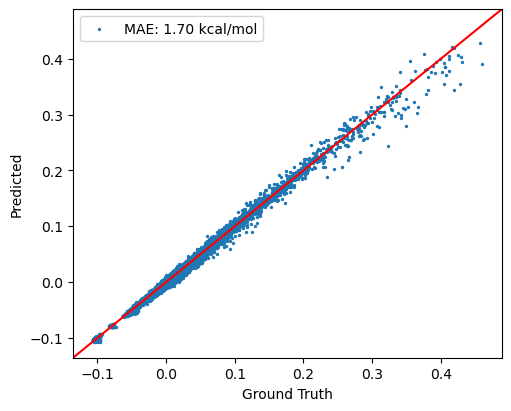

In [35]:
net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

# hyperparameters (best model)
learning_rate = 1e-3
epochs = 65 # Changed 50 to 60 epochs
l2_penalty = 1e-5

trainer = ANITrainer(
    model=model, 
    batch_size=batch_size, 
    learning_rate=learning_rate, 
    epoch=epochs, 
    l2=l2_penalty
)
print("Starting training via ANITrainer...")
train_losses, val_losses = trainer.train(
    train_data=train_heavy, 
    val_data=val_heavy, 
    early_stop=True, 
    draw_curve=True
)

test_loss = trainer.evaluate(data=test_heavy, draw_plot=True)

Other ANITrainer I made to train a model. This was an attempt to incorporate the filterring directrly into the trainer

Max heavy atoms of 2

In [36]:
data_heavy = load_ani_dataset2("./ani_gdb_s01_to_s04.h5", max_heavy_atoms=2)

total = len(data_heavy)
n_train = int(total * 0.8)
print(f"Total molecules: {total}")
print(f"Train size: {n_train}")
# Batch size should be a power of 2, no larger than train set
batch_size2 = min(8192, n_train)
# Round down to nearest power of 2 for GPU efficiency
batch_size2 = 2 ** (batch_size2.bit_length() - 1)

print(f"Using batch_size: {batch_size}")
# Pass None for last split so it consumes remainder, avoiding StopIteration from rounding
train_heavy, val_heavy, test_heavy = data_heavy.split(0.8, 0.1, 0.1)

train_data_loader = train_heavy.collate(batch_size2).cache()
val_data_loader = val_heavy.collate(batch_size2).cache()
test_data_loader  = test_heavy.collate(batch_size2).cache()

Total molecules: 61762
Train size: 49409
Using batch_size: 8192


Sequential - Number of parameters: 322308
Starting training via ANITrainer...
Initialize training data...


100%|██████████| 65/65 [00:31<00:00,  2.07it/s]


Final Train MAE: 2.96 kcal/mol
Final Val   MAE: 2.92 kcal/mol
func: train took: 34.6237 sec


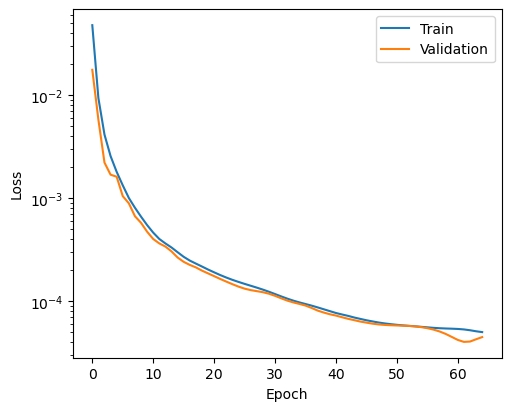

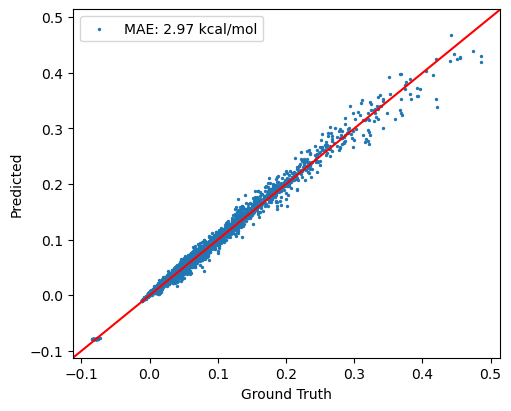

In [37]:
net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

# hyperparameters (best model)
learning_rate = 1e-3
epochs = 65 # Changed 50 to 60 epochs
l2_penalty = 1e-5

trainer = ANITrainer(
    model=model, 
    batch_size=batch_size, 
    learning_rate=learning_rate, 
    epoch=epochs, 
    l2=l2_penalty
)
print("Starting training via ANITrainer...")
train_losses, val_losses = trainer.train(
    train_data=train_heavy, 
    val_data=val_heavy, 
    early_stop=True, 
    draw_curve=True
)

test_loss = trainer.evaluate(data=test_heavy, draw_plot=True)

Max heavy atoms of 1

In [40]:
data_heavy = load_ani_dataset2("./ani_gdb_s01_to_s04.h5", max_heavy_atoms=1)

total = len(data_heavy)
n_train = int(total * 0.8)
print(f"Total molecules: {total}")
print(f"Train size: {n_train}")
# Batch size should be a power of 2, no larger than train set
batch_size2 = min(8192, n_train)
# Round down to nearest power of 2 for GPU efficiency
batch_size2 = 2 ** (batch_size2.bit_length() - 1)

print(f"Using batch_size: {batch_size}")
# Pass None for last split so it consumes remainder, avoiding StopIteration from rounding
train_heavy, val_heavy, test_heavy = data_heavy.split(0.8, 0.1, 0.1)

train_data_loader = train_heavy.collate(batch_size2).cache()
val_data_loader = val_heavy.collate(batch_size2).cache()
test_data_loader  = test_heavy.collate(batch_size2).cache()

Total molecules: 10800
Train size: 8640
Using batch_size: 8192


Sequential - Number of parameters: 322308
Starting training via ANITrainer...
Initialize training data...


100%|██████████| 65/65 [00:17<00:00,  3.64it/s]


Final Train MAE: 2.59 kcal/mol
Final Val   MAE: 2.74 kcal/mol
func: train took: 18.9669 sec


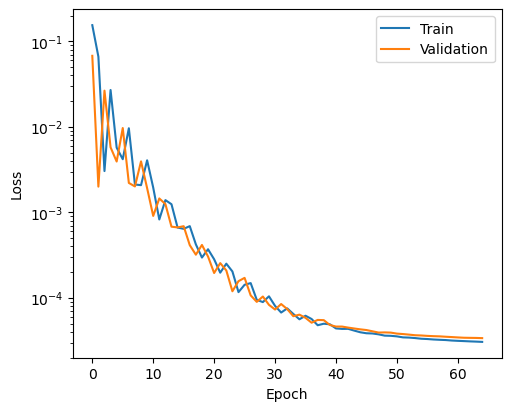

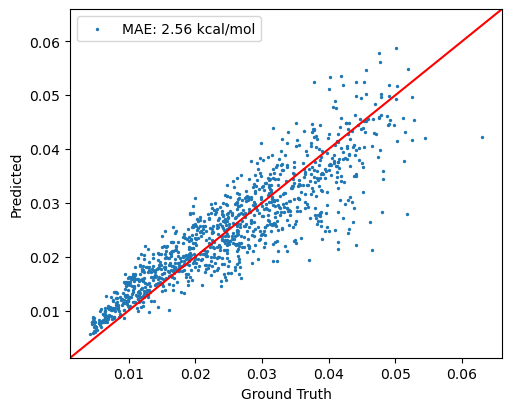

In [41]:
net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

# hyperparameters (best model)
learning_rate = 1e-3
epochs = 65 # Changed 50 to 60 epochs
l2_penalty = 1e-5

trainer = ANITrainer(
    model=model, 
    batch_size=batch_size, 
    learning_rate=learning_rate, 
    epoch=epochs, 
    l2=l2_penalty
)
print("Starting training via ANITrainer...")
train_losses, val_losses = trainer.train(
    train_data=train_heavy, 
    val_data=val_heavy, 
    early_stop=True, 
    draw_curve=True
)

test_loss = trainer.evaluate(data=test_heavy, draw_plot=True)

Plot of MAE vs # heavy atoms


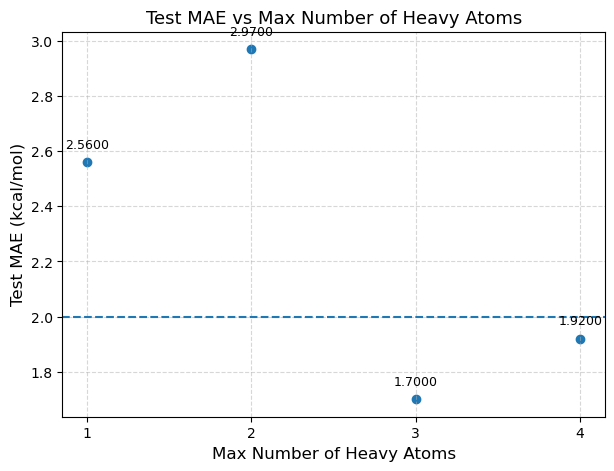

In [15]:
import matplotlib.pyplot as plt
import numpy as np

def plot_mae_vs_heavy_atoms(heavy_atoms, mae_values, units='kcal/mol'):
    """
    Plot test MAE vs number of heavy atoms.
        heavy_atoms:  list of max_heavy_atoms values e.g. [1, 2, 3, 4]
        mae_values:   corresponding MAE values        e.g. [0.5, 0.4, 0.3, 0.2]
        units:        energy units label (default 'kcal/mol')
    """
    fig, ax = plt.subplots(figsize=(7, 5))

    ax.scatter(heavy_atoms, mae_values, marker='o')

    for x, y in zip(heavy_atoms, mae_values):
        ax.annotate(f'{y:.4f}', xy=(x, y), xytext=(0, 10),
                    textcoords='offset points', ha='center', fontsize=9)

    ax.set_xlabel('Max Number of Heavy Atoms', fontsize=12)
    ax.set_ylabel(f'Test MAE ({units})', fontsize=12)
    ax.set_title('Test MAE vs Max Number of Heavy Atoms', fontsize=13)
    ax.set_xticks(heavy_atoms)
    ax.grid(True, linestyle='--', alpha=0.5)

    plt.axhline(2, ls = '--')
    plt.savefig('mae_vs_heavy_atoms.png', dpi=150)
    plt.show()

heavy_atoms = [1, 2, 3, 4]        # replace with your heavy atom counts
mae_values  = [2.56, 2.97, 1.7, 1.92]  # replace with your MAE values

plot_mae_vs_heavy_atoms(heavy_atoms, mae_values, units='kcal/mol')

**Analysis of modifying Heavy atoms**

using the same model as previously, decreasing the max_heavy-atoms not only decrease the amount of molecules the model is trained but also enables sa more accurate prediction because the energies from each of the molecules become more and more similar as the heavy atoms amount decreases. However, at heavy atom of 1 and 2, the model becomes less accurate, most likely due to the original network architecture.

**OTHER ATTEMPTS AT FILTERING (CAN BE IGNORED)**

In [ ]:
def filter_by_heavy_atoms(dataset, max_heavy=4):
    keep = []
    for batch in dataset.collate(8192).cache():
        species = batch['species']
        heavy = (species > 0).sum(dim=1)
        mask = heavy <= max_heavy
        if mask.any():
            keep.append({
                'species': batch['species'][mask],
                'coordinates': batch['coordinates'][mask],
                'energies': batch['energies'][mask],
            })
    return keep

In [35]:
class ANITrainerHeavy(ANITrainer):
    def __init__(self, model, batch_size, learning_rate, epoch, l2, max_heavy=4):
        super().__init__(model, batch_size, learning_rate, epoch, l2)
        self.max_heavy = max_heavy

    @timeit
    def train(self, train_data, val_data, early_stop=True, draw_curve=True):
        self.model.train()
        print("Filtering and initializing training data...")
        train_batches = filter_by_heavy_atoms(train_data, self.max_heavy)
        n_train = sum(b['species'].shape[0] for b in train_batches)
        loss_func = nn.MSELoss()
        train_loss_list = []
        val_loss_list = []
        lowest_val_loss = np.inf
        weights = None

        for i in tqdm(range(self.epoch), leave=True):
            train_epoch_loss = 0.0
            for batch in train_batches:
                species = batch['species'].to(device)
                coords = batch['coordinates'].to(device)
                true_energies = batch['energies'].to(device).float()
                _, pred_energies = self.model((species, coords))
                batch_loss = loss_func(pred_energies, true_energies)
                self.optimizer.zero_grad()
                batch_loss.backward()
                self.optimizer.step()
                batch_importance = true_energies.shape[0] / n_train
                train_epoch_loss += batch_loss.detach().cpu().item() * batch_importance

            val_epoch_loss = self.evaluate(val_data, draw_plot=False)
            train_loss_list.append(train_epoch_loss)
            val_loss_list.append(val_epoch_loss)

            if early_stop and val_epoch_loss < lowest_val_loss:
                lowest_val_loss = val_epoch_loss
                weights = self.model.state_dict()

        if draw_curve:
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.set_yscale("log")
            ax.plot(np.arange(self.epoch), train_loss_list, label='Train')
            ax.plot(np.arange(self.epoch), val_loss_list, label='Validation')
            ax.legend()
            ax.set_xlabel("# Epoch")
            ax.set_ylabel("Loss")

        if early_stop:
            self.model.load_state_dict(weights)

        return train_loss_list, val_loss_list
        
    def compute_mae_filtered(self, data): 
        """MAE in kcal/mol, filtered to only molecules within max_heavy."""
        hartree2kcalmol = 627.5094738898777
        batches = filter_by_heavy_atoms(data, self.max_heavy)
        true_all, pred_all = [], []
        self.model.eval()
        with torch.no_grad():
            for batch in batches:
                species = batch['species'].to(device)
                coords = batch['coordinates'].to(device)
                true_e = batch['energies'].to(device).float()
                _, pred_e = self.model((species, coords))
                true_all.append(true_e.cpu().numpy().flatten())
                pred_all.append(pred_e.cpu().numpy().flatten())
        true_all = np.concatenate(true_all)
        pred_all = np.concatenate(pred_all)
        filtered_mae = float(np.mean(np.abs(hartree2kcalmol * (true_all - pred_all))))
        return filtered_mae

Sequential - Number of parameters: 322308
Filtering and initializing training data...


100%|██████████| 65/65 [06:20<00:00,  5.86s/it]


func: train took: 397.3705 sec
FINAL METRICS
Split      MAE (kcal/mol)
Train               3.901
Val                 3.905
Test                3.902

── MAE by Heavy Atom Count ──
  1 heavy atoms: MAE = 2.881 kcal/mol (1057 molecules)
  2 heavy atoms: MAE = 4.487 kcal/mol (5160 molecules)
  3 heavy atoms: MAE = 3.318 kcal/mol (15116 molecules)
  4 heavy atoms: MAE = 4.007 kcal/mol (65156 molecules)


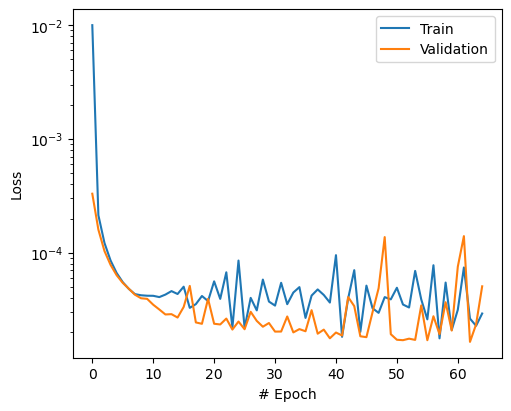

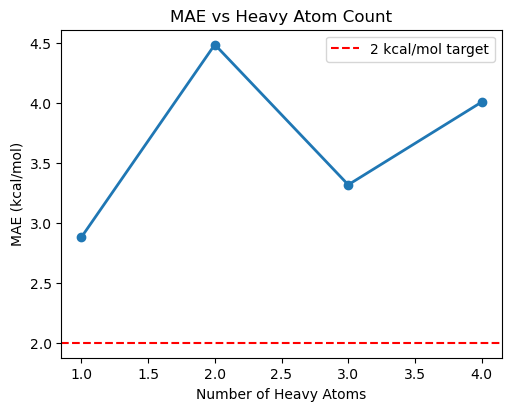

In [36]:
# Max Heavy Atoms is 4 (result should be similar to previous)
# initialize
net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(aev_computer, ani_net).to(device)

trainer = ANITrainerHeavy(
    model=model,
    batch_size=batch_size,
    learning_rate=1e-3,
    epoch=65,
    l2=1e-5,
    max_heavy=4  
)

train_losses, val_losses = trainer.train(
    train_data=train_data,
    val_data=val_data,
    early_stop=True,
    draw_curve=True
)

train_mae = trainer.compute_mae_filtered(train_data)
val_mae = trainer.compute_mae_filtered(val_data)
test_mae = trainer.compute_mae_filtered(test_data)

print("FINAL METRICS")
print(f"{'Split':<8} {'MAE (kcal/mol)':>16}")
print(f"{'Train':<8} {train_mae:>16.3f}")
print(f"{'Val':<8} {val_mae:>16.3f}")
print(f"{'Test':<8} {test_mae:>16.3f}") 

_ = trainer.evaluate_by_heavy_atoms(test_data, max_heavy=4) # just to plot

Sequential - Number of parameters: 322308
Filtering and initializing training data...


100%|██████████| 65/65 [03:35<00:00,  3.32s/it]


func: train took: 232.3780 sec
FINAL METRICS
Split      MAE (kcal/mol)
Train               3.275
Val                 3.239
Test                3.301

── MAE by Heavy Atom Count ──
  1 heavy atoms: MAE = 2.409 kcal/mol (1065 molecules)
  2 heavy atoms: MAE = 3.699 kcal/mol (5105 molecules)
  3 heavy atoms: MAE = 3.230 kcal/mol (15213 molecules)


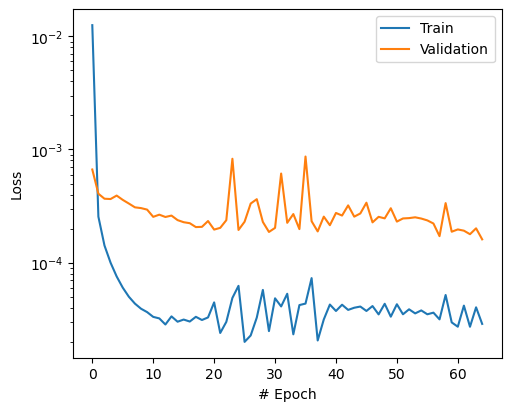

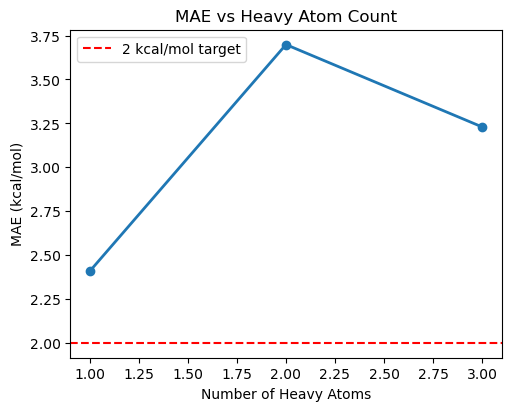

In [31]:
# Max Heavy Atoms is 3
# initialize
net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(aev_computer, ani_net).to(device)

trainer = ANITrainerHeavy(
    model=model,
    batch_size=batch_size,
    learning_rate=1e-3,
    epoch=65,
    l2=1e-5,
    max_heavy=3   
)

train_losses, val_losses = trainer.train(
    train_data=train_data,
    val_data=val_data,
    early_stop=True,
    draw_curve=True
)

train_mae = trainer.compute_mae_filtered(train_data)
val_mae = trainer.compute_mae_filtered(val_data)
test_mae = trainer.compute_mae_filtered(test_data)

print("FINAL METRICS")
print(f"{'Split':<8} {'MAE (kcal/mol)':>16}")
print(f"{'Train':<8} {train_mae:>16.3f}")
print(f"{'Val':<8} {val_mae:>16.3f}")
print(f"{'Test':<8} {test_mae:>16.3f}") 

_ = trainer.evaluate_by_heavy_atoms(test_data, max_heavy=3) 

Sequential - Number of parameters: 322308
Filtering and initializing training data...


100%|██████████| 65/65 [03:36<00:00,  3.33s/it]


func: train took: 232.5691 sec
FINAL METRICS
Split      MAE (kcal/mol)
Train               1.719
Val                 1.770
Test                1.758

── MAE by Heavy Atom Count ──
  1 heavy atoms: MAE = 1.360 kcal/mol (1057 molecules)
  2 heavy atoms: MAE = 1.839 kcal/mol (5160 molecules)


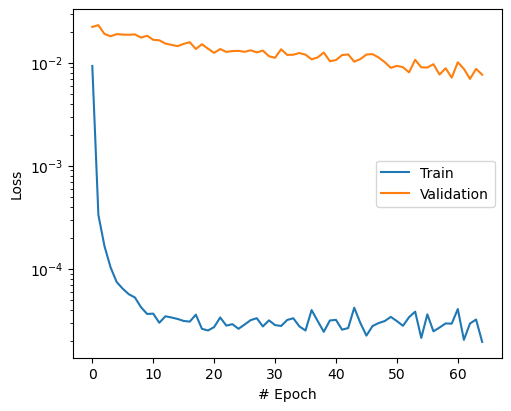

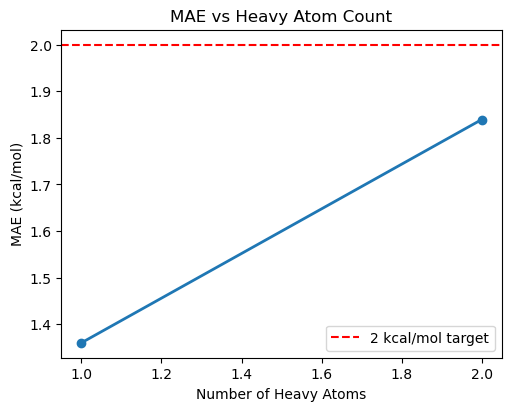

In [37]:
# Max Heavy Atoms is 2
# initialize
net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(aev_computer, ani_net).to(device)

trainer = ANITrainerHeavy(
    model=model,
    batch_size=batch_size,
    learning_rate=1e-3,
    epoch=65,
    l2=1e-5,
    max_heavy=2   
)

train_losses, val_losses = trainer.train(
    train_data=train_data,
    val_data=val_data,
    early_stop=True,
    draw_curve=True
)
train_mae = trainer.compute_mae_filtered(train_data)
val_mae = trainer.compute_mae_filtered(val_data)
test_mae = trainer.compute_mae_filtered(test_data)

print("FINAL METRICS")
print(f"{'Split':<8} {'MAE (kcal/mol)':>16}")
print(f"{'Train':<8} {train_mae:>16.3f}")
print(f"{'Val':<8} {val_mae:>16.3f}")
print(f"{'Test':<8} {test_mae:>16.3f}") 

_ = trainer.evaluate_by_heavy_atoms(test_data, max_heavy=2)

Observation: Training time significantly increases as max_heavy decreases because the number of qualified molecules decreases, reducing the size of the dataset.

In [ ]:
net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

# hyperparameters
learning_rate = 2e-3
epochs = 60 # start with 50
l2_penalty = 1e-5

trainer = ANITrainer(
    model=model, 
    batch_size=batch_size, 
    learning_rate=learning_rate, 
    epoch=epochs, 
    l2=l2_penalty
)
print("Starting training via ANITrainer...")
train_losses, val_losses = trainer.train(
    train_data=train_data, 
    val_data=val_data, 
    early_stop=True, 
    draw_curve=True
)

test_loss = trainer.evaluate(data=test_data, draw_plot=True)